# 15. Resumen de ablaciones experimentales

Este notebook recopila los experimentos principales ya generados en el repositorio y los organiza como una narrativa de ablacion.

Objetivo: mostrar que la evaluacion no es solo una pipeline de generacion de pseudo-LiDAR, sino un analisis experimental desde varios angulos:
1. calidad geometrica frente a LiDAR real;
2. consistencia temporal usando pose real;
3. capacidad de registro mediante ICP y trayectoria acumulada.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.options.display.float_format = '{:.3f}'.format

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
BASE_DIR = ROOT / 'outputs' / 'scene-0061'

def load_json(name):
    return json.loads((BASE_DIR / name).read_text(encoding='utf-8-sig'))

depth_cmp = load_json('depth_model_comparison_common_support.json')
subset = load_json('subset_registration_comparison.json')
region = load_json('pairwise_region_analysis.json')
front_strategy = load_json('front_registration_strategies.json')
point_sel = load_json('front_point_selection_comparison.json')
param_sweep = load_json('front_global_icp_param_sweep.json')
front_best = load_json('front_best_combination.json')
trajectory = load_json('accumulated_trajectory_comparison.json')
temporal = load_json('temporal_consistency_metrics.json')
lidar_baseline = load_json('lidar_registration_baseline.json')
pairwise = load_json('pairwise_registration_metrics.json')


## 1. Modelo de profundidad

Primero se compara la geometria resultante de Depth Pro y Depth Anything 3 frente a `LIDAR_TOP` en soporte comun. Esta comparacion justifica mantener Depth Pro como rama principal.

In [2]:
depth_rows = []
for model, metrics in depth_cmp['models'].items():
    depth_rows.append({'configuracion': model, **metrics})
depth_df = pd.DataFrame(depth_rows).set_index('configuracion')
display(depth_df[['pseudo_points', 'pseudo_to_gt_median_nn', 'gt_to_pseudo_median_nn', 'bev_iou']])

,pseudo_points,pseudo_to_gt_median_nn,gt_to_pseudo_median_nn,bev_iou
configuracion,,,,
Depth Pro,14275,0.518,0.771,0.236
Depth Anything 3,14250,0.632,0.791,0.227


## 2. Baseline con LiDAR real

El LiDAR real actua como referencia de geometria fiable. Si el mismo backend de registro funciona mucho mejor con `LIDAR_TOP` que con pseudo-LiDAR, entonces parte del error procede de la representacion generada desde camaras y no solo del algoritmo ICP.

In [3]:
lidar_rows = []
for method, regions in lidar_baseline['aggregate'].items():
    for region_name, metrics in regions.items():
        lidar_rows.append({'configuracion': f'LiDAR {region_name} + {method}', **metrics})
lidar_df = pd.DataFrame(lidar_rows).set_index('configuracion')
display(lidar_df.loc[['LiDAR all + icp_direct', 'LiDAR all + global_then_icp']])

,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,rmse_mean,num_source_points_mean,num_target_points_mean,num_valid_pairs
configuracion,,,,,,,
LiDAR all + icp_direct,0.065,0.216,0.864,0.566,34704.000,34720.000,4
LiDAR all + global_then_icp,0.066,0.217,0.864,0.567,34704.000,34720.000,4


### Comparacion directa con LiDAR normal

Esta tabla compara el registro temporal usando el LiDAR real de nuScenes (`LIDAR_TOP`) frente a la pseudo-LiDAR generada desde camaras. Es una ablacion importante porque mantiene el mismo problema de registro y cambia principalmente la calidad de la geometria de entrada.

,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,num_valid_pairs
configuracion,,,,
LiDAR real completo + ICP,0.065,0.216,0.864,4
pseudo-LiDAR completo + ICP,1.506,1.274,0.754,4
pseudo-LiDAR frontal cfg05,1.179,1.598,0.748,4


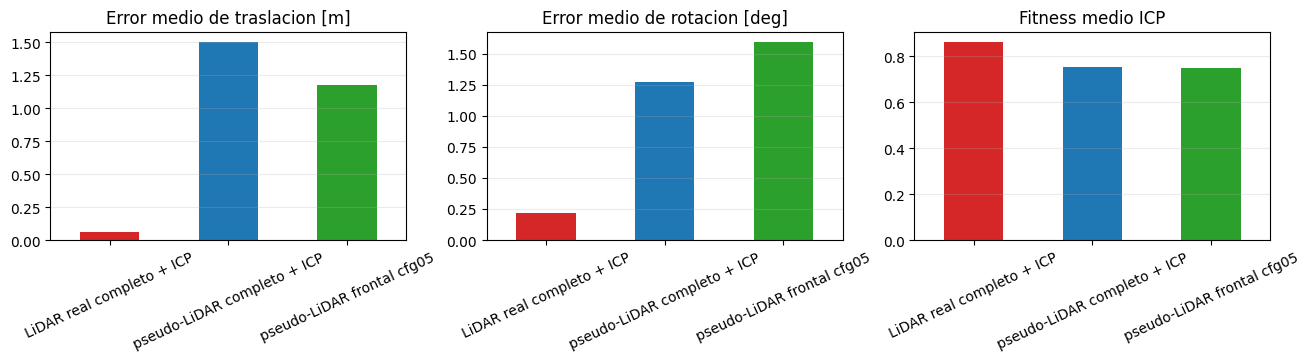

In [4]:
lidar_normal_comparison = pd.DataFrame([
    {
        'configuracion': 'LiDAR real completo + ICP',
        'translation_error_mean_m': pairwise['aggregate']['gt_translation_error_mean_m'],
        'rotation_error_mean_deg': pairwise['aggregate']['gt_rotation_error_mean_deg'],
        'fitness_mean': pairwise['aggregate']['gt_fitness_mean'],
        'num_valid_pairs': pairwise['num_pairs'],
    },
    {
        'configuracion': 'pseudo-LiDAR completo + ICP',
        'translation_error_mean_m': pairwise['aggregate']['pseudo_translation_error_mean_m'],
        'rotation_error_mean_deg': pairwise['aggregate']['pseudo_rotation_error_mean_deg'],
        'fitness_mean': pairwise['aggregate']['pseudo_fitness_mean'],
        'num_valid_pairs': pairwise['num_pairs'],
    },
    {
        'configuracion': 'pseudo-LiDAR frontal cfg05',
        'translation_error_mean_m': front_best['aggregate']['front_baseline_cfg05']['translation_error_mean_m'],
        'rotation_error_mean_deg': front_best['aggregate']['front_baseline_cfg05']['rotation_error_mean_deg'],
        'fitness_mean': front_best['aggregate']['front_baseline_cfg05']['fitness_mean'],
        'num_valid_pairs': front_best['aggregate']['front_baseline_cfg05']['num_valid_pairs'],
    },
]).set_index('configuracion')

display(lidar_normal_comparison)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
plot_cols = [
    ('translation_error_mean_m', 'Error medio de traslacion [m]'),
    ('rotation_error_mean_deg', 'Error medio de rotacion [deg]'),
    ('fitness_mean', 'Fitness medio ICP'),
]

for ax, (col, title) in zip(axes, plot_cols):
    lidar_normal_comparison[col].plot(kind='bar', ax=ax, color=['tab:red', 'tab:blue', 'tab:green'])
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.25)

plt.show()

## 3. Cobertura espacial: anillo completo frente a region frontal

El objetivo de esta ablacion es comprobar si usar mas cobertura espacial implica necesariamente mejor registro. En estos resultados, el anillo completo no es la opcion mas estable para estimar movimiento.

In [5]:
subset_rows = []
for name, metrics in subset['aggregate'].items():
    subset_rows.append({'configuracion': name, **metrics})
subset_df = pd.DataFrame(subset_rows).set_index('configuracion')
display(subset_df)

,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,num_valid_pairs
configuracion,,,,
all,2.179,3.594,0.799,4
front,1.906,2.330,0.752,4
front_left,1.953,2.678,0.763,4
front_right,2.540,2.775,0.801,4


## 4. Estrategia de registro

Aqui se compara ICP directo con una variante que usa alineacion global y despues ICP. La comparacion mas estable se toma de las configuraciones ajustadas (`cfg_05` / mejores variantes), no de una unica ejecucion aislada de RANSAC.

In [6]:
best_cfg = min(param_sweep['configs'], key=lambda item: item['aggregate']['translation_error_mean_m'])

def registration_row(configuracion, metrics, interpretacion, rmse_available=True):
    return {
        'configuracion': configuracion,
        'translation_error_mean_m': metrics['translation_error_mean_m'],
        'rotation_error_mean_deg': metrics['rotation_error_mean_deg'],
        'fitness_mean': metrics['fitness_mean'],
        'rmse_mean': metrics.get('rmse_mean', 'no disponible') if rmse_available else 'no disponible',
        'num_valid_pairs': metrics['num_valid_pairs'],
        'interpretacion': interpretacion,
    }

registration_rows = [
    registration_row(
        'LiDAR all + ICP',
        lidar_baseline['aggregate']['icp_direct']['all'],
        'baseline con geometria real completa',
    ),
    registration_row(
        'LiDAR all + global+ICP',
        lidar_baseline['aggregate']['global_then_icp']['all'],
        'baseline LiDAR con inicializacion global',
    ),
    {
        'configuracion': 'pseudo all + ICP',
        'translation_error_mean_m': pairwise['aggregate']['pseudo_translation_error_mean_m'],
        'rotation_error_mean_deg': pairwise['aggregate']['pseudo_rotation_error_mean_deg'],
        'fitness_mean': pairwise['aggregate']['pseudo_fitness_mean'],
        'rmse_mean': 'no disponible',
        'num_valid_pairs': pairwise['num_pairs'],
        'interpretacion': 'pseudo-LiDAR completa con ICP directo',
    },
    {
        'configuracion': 'front_icp_only',
        'translation_error_mean_m': front_strategy['aggregate']['front_icp_only_translation_error_mean_m'],
        'rotation_error_mean_deg': front_strategy['aggregate']['front_icp_only_rotation_error_mean_deg'],
        'fitness_mean': front_strategy['aggregate']['front_icp_only_fitness_mean'],
        'rmse_mean': 'no disponible',
        'num_valid_pairs': front_strategy['num_pairs'],
        'interpretacion': 'ICP directo sobre region frontal',
    },
    registration_row(best_cfg['name'], best_cfg['aggregate'], 'alineacion global + ICP con mejor barrido local'),
    registration_row('front_baseline_cfg05', front_best['aggregate']['front_baseline_cfg05'], 'configuracion final equilibrada'),
    registration_row('front_narrow_cfg05', front_best['aggregate']['front_narrow_cfg05'], 'seleccion mas estricta; buena por pares, menos estable acumulada'),
]
registration_df = pd.DataFrame(registration_rows).set_index('configuracion')
display(registration_df)


,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,rmse_mean,num_valid_pairs,interpretacion
configuracion,,,,,,
LiDAR all + ICP,0.065,0.216,0.864,0.566,4,baseline con geometria real completa
LiDAR all + global+ICP,0.066,0.217,0.864,0.567,4,baseline LiDAR con inicializacion global
pseudo all + ICP,1.506,1.274,0.754,no disponible,4,pseudo-LiDAR completa con ICP directo
front_icp_only,1.906,2.330,0.752,no disponible,4,ICP directo sobre region frontal
cfg_05,1.175,1.607,0.748,0.620,4,alineacion global + ICP con mejor barrido local
front_baseline_cfg05,1.179,1.598,0.748,0.620,4,configuracion final equilibrada
front_narrow_cfg05,1.223,1.680,0.800,0.609,4,"seleccion mas estricta; buena por pares, menos..."


## 5. Seleccion de puntos dentro de la region frontal

Esta ablacion evalua si conviene usar toda la region frontal o una seleccion mas restringida. El resultado local por pares no siempre coincide con el comportamiento acumulado.

In [7]:
point_rows = []
for name, metrics in point_sel['aggregate'].items():
    point_rows.append({'configuracion': name, **metrics})
point_df = pd.DataFrame(point_rows).set_index('configuracion').sort_values('translation_error_mean_m')
display(point_df)

,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,rmse_mean,num_valid_pairs
configuracion,,,,,
front_narrow,1.249,1.590,0.800,0.613,4
front_baseline,1.450,2.985,0.753,0.640,4
front_compact,1.529,1.840,0.760,0.616,4
front_midrange,2.042,2.750,0.740,0.629,4
front_above_ground,6.537,46.224,0.721,0.689,4


## 6. Consistencia temporal con pose real

Este bloque separa la calidad temporal de la pseudo-LiDAR del error introducido por ICP. Si una region ya es incoherente usando la pose real, es dificil que un registro posterior sea robusto.

In [8]:
temporal_rows = []
for name, metrics in temporal['aggregate'].items():
    if metrics is not None:
        temporal_rows.append({'region': name, **metrics})
temporal_df = pd.DataFrame(temporal_rows).set_index('region')
display(temporal_df[['mean_nn_m', 'median_nn_m', 'p90_nn_m', 'overlap_ratio_0p5m', 'overlap_ratio_1p0m']])

,mean_nn_m,median_nn_m,p90_nn_m,overlap_ratio_0p5m,overlap_ratio_1p0m
region,,,,,
all,0.908,0.488,2.354,0.515,0.728
front,0.710,0.367,1.858,0.611,0.794
near,0.494,0.270,1.186,0.730,0.881
mid,1.278,0.738,3.174,0.387,0.643
far,1.860,1.124,3.720,0.211,0.486
left,1.100,0.572,2.878,0.481,0.686
right,0.735,0.454,1.724,0.540,0.767


## 7. Trayectoria acumulada

El registro por parejas no basta para evaluar utilidad tipo SLAM. Tambien hay que mirar como se acumula el error al encadenar transformaciones.

In [9]:
traj_rows = []
for name, data in trajectory['trajectories'].items():
    traj_rows.append({'configuracion': name, **data['aggregate']})
traj_df = pd.DataFrame(traj_rows).set_index('configuracion')
display(traj_df)
print('Configuracion recomendada por el analisis acumulado:', trajectory.get('best_recommendation'))

,mean_translation_error_m,mean_rotation_error_deg,final_translation_error_m,final_rotation_error_deg,num_frames
configuracion,,,,,
front_icp_only,4.716,5.206,6.583,5.526,5
front_baseline_cfg05,2.060,2.856,3.913,3.709,5
front_narrow_cfg05,1.683,3.272,4.289,5.071,5


Configuracion recomendada por el analisis acumulado: front_baseline_cfg05


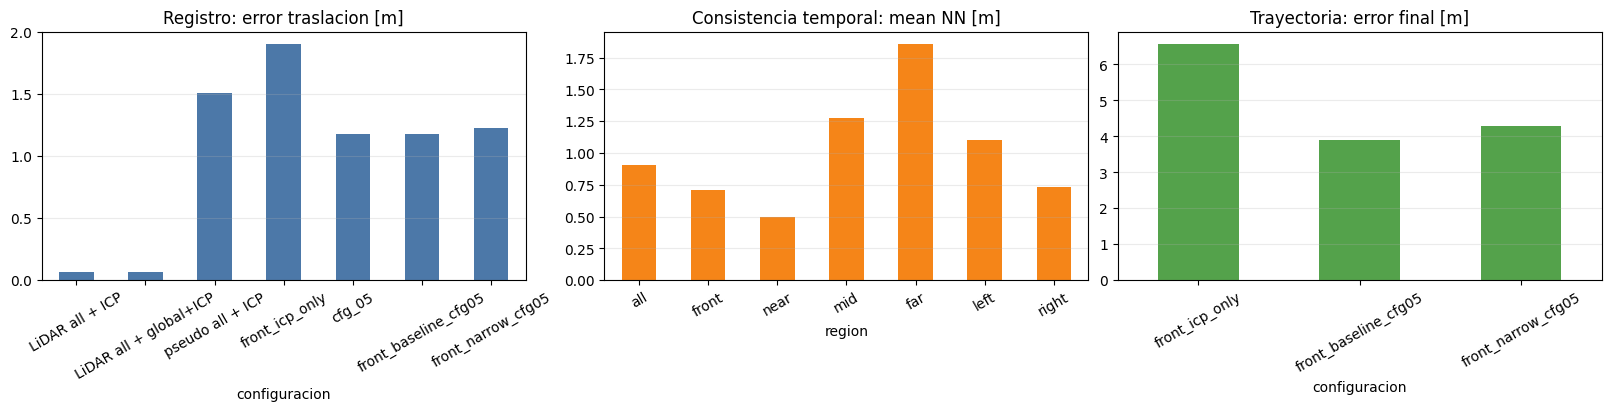

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
registration_df['translation_error_mean_m'].dropna().plot(kind='bar', ax=axes[0], color='#4C78A8', title='Registro: error traslacion [m]')
temporal_df['mean_nn_m'].plot(kind='bar', ax=axes[1], color='#F58518', title='Consistencia temporal: mean NN [m]')
traj_df['final_translation_error_m'].plot(kind='bar', ax=axes[2], color='#54A24B', title='Trayectoria: error final [m]')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.25)
plt.show()

## Lectura conjunta

La narrativa experimental queda asi:
- el LiDAR real con nube completa actua como limite superior practico para el backend de registro;
- la pseudo-LiDAR queda claramente por debajo del LiDAR real, lo que apunta a limitaciones de geometria y consistencia temporal;
- mas cobertura no implica mejor registro: el anillo completo puede introducir regiones menos fiables;
- la region frontal mejora frente al anillo completo en varios analisis;
- una inicializacion global seguida de ICP puede mejorar el registro si se ajusta correctamente;
- la configuracion localmente mejor por pares no siempre es la mas estable al acumular trayectoria;
- la consistencia temporal explica parte de los errores de registro, especialmente en zonas lejanas o menos estables.
